# BART Ridership in 2025: From Weekly Patterns to an Unexpected Sunday

This notebook begins a portfolio-focused analysis of 2025 Bay Area Rapid Transit (BART) ridership. It uses the same data and descriptive methods developed in `exploration.ipynb`, while organizing the temporal analysis into a reproducible narrative.

The analysis follows the questions that emerged while exploring the data:

1. How does systemwide ridership vary across days of the week?
2. Which dates look unusual relative to their normal weekday pattern?
3. What might explain the most unusual Sunday, and which stations account for the difference?

This is an observational, exploratory analysis. It describes patterns in the available trip counts; it does not attempt to estimate a causal effect of Pride or other events.

## 1. Data loading

The source file is a compressed, headerless CSV. Each row records a trip count for one date, hour, origin station, and destination station combination.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../data/date-hour-soo-dest-2025.csv.gz")
COLUMN_NAMES = ["date", "hour", "origin", "destination", "trips"]

bart = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLUMN_NAMES,
    parse_dates=["date"],
)

bart.head()

,date,hour,origin,destination,trips
0,2025-01-01,0,12TH,16TH,1
1,2025-01-01,0,12TH,ANTC,1
2,2025-01-01,0,12TH,BALB,1
3,2025-01-01,0,12TH,BERY,1
4,2025-01-01,0,12TH,CIVC,8


## 2. Basic validation

Before aggregating the records, we check the dataset's coverage and several assumptions used later in the notebook. These checks are intentionally simple and readable: the data should cover all of 2025, contain all 24 hours, use the same station set for origins and destinations, contain no missing values, and have positive trip counts.

In [2]:
expected_dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
actual_dates = pd.DatetimeIndex(bart["date"].unique()).sort_values()
origin_stations = set(bart["origin"].unique())
destination_stations = set(bart["destination"].unique())

validation_summary = pd.Series(
    {
        "Rows": f"{len(bart):,}",
        "Start date": bart["date"].min().date(),
        "End date": bart["date"].max().date(),
        "Calendar days": bart["date"].nunique(),
        "Distinct hours": bart["hour"].nunique(),
        "Origin stations": len(origin_stations),
        "Destination stations": len(destination_stations),
        "Missing values": int(bart.isna().sum().sum()),
        "Nonpositive trip rows": int((bart["trips"] <= 0).sum()),
        "Total trips": f"{bart['trips'].sum():,}",
    },
    name="Value",
)

assert actual_dates.equals(expected_dates)
assert set(bart["hour"].unique()) == set(range(24))
assert origin_stations == destination_stations
assert bart.isna().sum().sum() == 0
assert (bart["trips"] > 0).all()

validation_summary.to_frame()

,Value
Rows,"9,143,257"
Start date,2025-01-01
End date,2025-12-31
Calendar days,365
Distinct hours,24
Origin stations,50
Destination stations,50
Missing values,0
Nonpositive trip rows,0
Total trips,"54,507,357"


## 3. Systemwide daily ridership

The raw data contains origin-destination counts by hour. Summing across hours and station pairs gives one total for each calendar day. The highest and lowest days provide context before we compare weekdays.

In [3]:
daily = bart.groupby("date", as_index=False)["trips"].sum()
daily["weekday"] = daily["date"].dt.day_name()

daily["trips"].describe().round(0).to_frame(name="Daily trips")

,Daily trips
count,365.0
mean,149335.0
std,47197.0
min,28313.0
25%,104536.0
50%,163203.0
75%,193110.0
max,211140.0


In [4]:
highest_days = daily.nlargest(5, "trips").assign(group="Highest")
lowest_days = daily.nsmallest(5, "trips").assign(group="Lowest")

daily_extremes = pd.concat([highest_days, lowest_days], ignore_index=True)
daily_extremes[["group", "date", "weekday", "trips"]]

,group,date,weekday,trips
0,Highest,2025-05-01,Thursday,211140
1,Highest,2025-09-10,Wednesday,209238
2,Highest,2025-08-19,Tuesday,208273
3,Highest,2025-04-30,Wednesday,207622
4,Highest,2025-04-22,Tuesday,207503
5,Lowest,2025-12-25,Thursday,28313
6,Lowest,2025-11-27,Thursday,44879
7,Lowest,2025-02-02,Sunday,55565
8,Lowest,2025-12-28,Sunday,55648
9,Lowest,2025-12-21,Sunday,57021


## 4. Ridership by weekday

The lowest raw daily totals include Christmas, Thanksgiving, and several Sundays. That list mixes two different effects: genuinely unusual dates and the fact that Sundays normally have fewer trips. Comparing each date with others from the same weekday gives the outliers more useful context. Means describe the average level for each weekday, while medians are less affected by unusually quiet holidays or unusually busy event days. The boxplot shows the full distribution rather than only one summary value.

In [5]:
weekdays = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_summary = (
    daily.groupby("weekday")["trips"]
    .agg(days="count", mean="mean", median="median", minimum="min", maximum="max")
    .reindex(weekdays)
    .round(0)
)
weekday_summary["days"] = weekday_summary["days"].astype(int)
weekday_summary

,days,mean,median,minimum,maximum
weekday,,,,,
Monday,52,153566.0,163794.0,70188,173933
Tuesday,52,188212.0,196684.0,103414,208273
Wednesday,53,187033.0,197141.0,58039,209238
Thursday,52,183429.0,193492.0,28313,211140
Friday,52,149918.0,157883.0,70556,173848
Saturday,52,104972.0,104908.0,68269,141986
Sunday,52,77492.0,77744.0,55565,141474


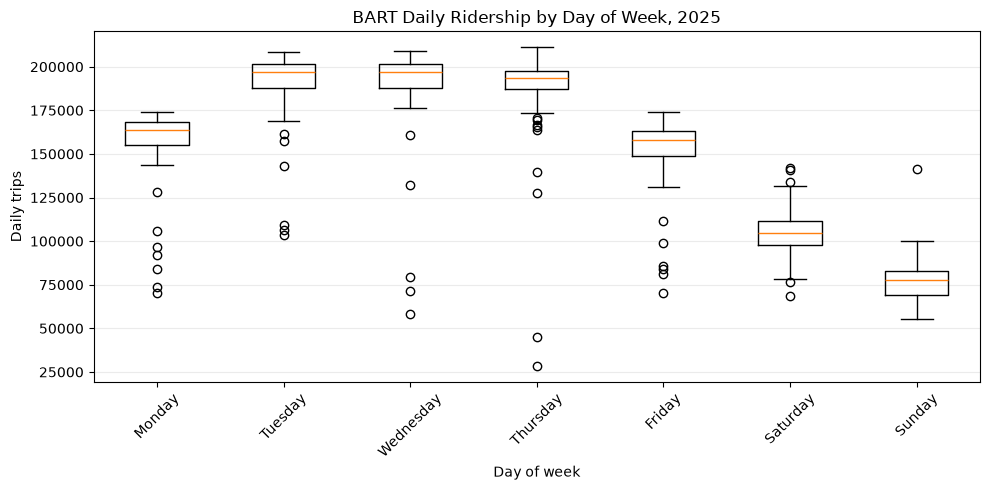

In [6]:
weekday_trips = [
    daily.loc[daily["weekday"] == day, "trips"]
    for day in weekdays
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(weekday_trips, tick_labels=weekdays)
ax.set(
    title="BART Daily Ridership by Day of Week, 2025",
    xlabel="Day of week",
    ylabel="Daily trips",
)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

Tuesday through Thursday have the highest typical ridership, while weekend ridership is lower. The points beyond the boxplot whiskers are dates worth checking: many low points have recognizable calendar explanations, while one unusually high Sunday does not initially have an obvious explanation.

## 5. Following up on unusual dates

The original exploration involved looking up dates that appeared unusual in the weekday boxplot. The code below surfaces the same points shown beyond the boxplot's standard 1.5-IQR whiskers. The context labels are not a comprehensive event calendar; they record several immediately recognizable holidays that helped explain many of the low-ridership dates.

In [7]:
calendar_context = {
    pd.Timestamp("2025-01-01"): "New Year's Day",
    pd.Timestamp("2025-01-20"): "Martin Luther King Jr. Day",
    pd.Timestamp("2025-02-17"): "Presidents' Day",
    pd.Timestamp("2025-05-26"): "Memorial Day",
    pd.Timestamp("2025-06-19"): "Juneteenth",
    pd.Timestamp("2025-07-04"): "Independence Day",
    pd.Timestamp("2025-09-01"): "Labor Day",
    pd.Timestamp("2025-11-11"): "Veterans Day",
    pd.Timestamp("2025-11-27"): "Thanksgiving",
    pd.Timestamp("2025-12-25"): "Christmas Day",
}

outlier_groups = []

for day in weekdays:
    group = daily.loc[daily["weekday"] == day]
    first_quartile = group["trips"].quantile(0.25)
    third_quartile = group["trips"].quantile(0.75)
    interquartile_range = third_quartile - first_quartile
    lower_bound = first_quartile - 1.5 * interquartile_range
    upper_bound = third_quartile + 1.5 * interquartile_range

    outliers = group.loc[
        (group["trips"] < lower_bound) | (group["trips"] > upper_bound)
    ].copy()
    outliers["direction"] = "High"
    outliers.loc[outliers["trips"] < lower_bound, "direction"] = "Low"
    outlier_groups.append(outliers)

weekday_outliers = pd.concat(outlier_groups, ignore_index=True)
weekday_outliers["context"] = weekday_outliers["date"].map(calendar_context)

outliers_to_review = weekday_outliers.loc[
    weekday_outliers["context"].notna()
    | (weekday_outliers["weekday"] == "Sunday")
].sort_values("date")

outliers_to_review[["date", "weekday", "trips", "direction", "context"]].fillna("")

,date,weekday,trips,direction,context
13,2025-01-01,Wednesday,58039,Low,New Year's Day
0,2025-01-20,Monday,83940,Low,Martin Luther King Jr. Day
1,2025-02-17,Monday,92206,Low,Presidents' Day
2,2025-05-26,Monday,70188,Low,Memorial Day
21,2025-06-19,Thursday,139910,Low,Juneteenth
38,2025-06-29,Sunday,141474,High,
29,2025-07-04,Friday,85510,Low,Independence Day
3,2025-09-01,Monday,73707,Low,Labor Day
9,2025-11-11,Tuesday,143283,Low,Veterans Day
24,2025-11-27,Thursday,44879,Low,Thanksgiving


Most of the readily explained dates are low-ridership holidays. June 29 is different: it is the only Sunday beyond the upper boxplot whisker, and at this stage of the exploration it is simply an unexplained date in the data. That makes Sundays the next place to look.

## 6. An unexpected Sunday

After setting aside several low outliers with recognizable calendar explanations, the high Sunday remains unusual. We isolate Sundays and rank them by total ridership without choosing a target date in advance.

In [8]:
sundays = daily.loc[daily["weekday"] == "Sunday"].copy()
sunday_ranking = sundays.nlargest(10, "trips")[["date", "trips"]]
sunday_ranking

,date,trips
179,2025-06-29,141474
144,2025-05-25,99835
137,2025-05-18,98443
207,2025-07-27,94866
221,2025-08-10,92340
172,2025-06-22,87870
228,2025-08-17,86925
214,2025-08-03,86414
270,2025-09-28,86199
242,2025-08-31,85304


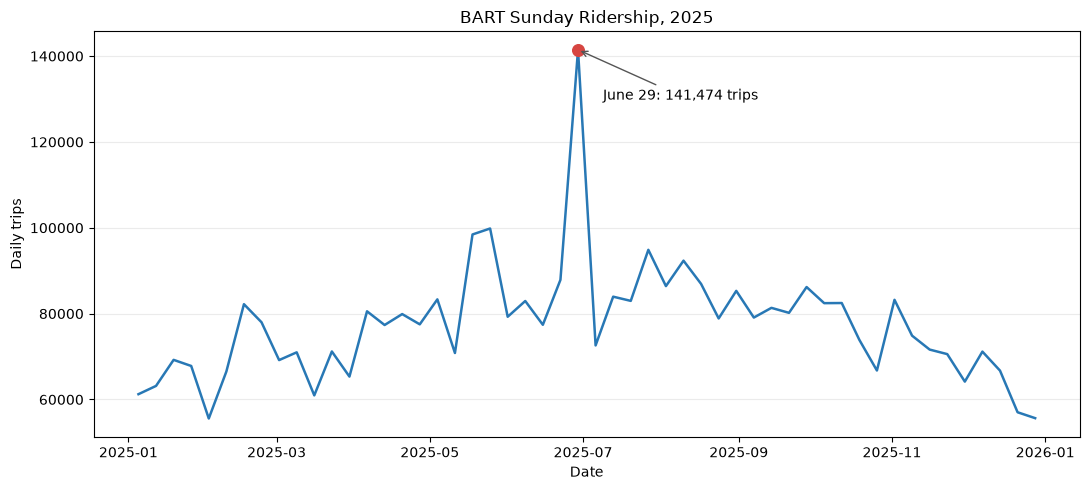

In [9]:
anomaly_date = sunday_ranking.iloc[0]["date"]
anomaly_daily_trips = int(sunday_ranking.iloc[0]["trips"])
anomaly_label = f"{anomaly_date:%B} {anomaly_date.day}"

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sundays["date"], sundays["trips"], color="#2878B5", linewidth=1.8)
ax.scatter(anomaly_date, anomaly_daily_trips, color="#D64541", s=70, zorder=3)
ax.annotate(
    f"{anomaly_label}: {anomaly_daily_trips:,} trips",
    xy=(anomaly_date, anomaly_daily_trips),
    xytext=(18, -28),
    textcoords="offset points",
    verticalalignment="top",
    arrowprops={"arrowstyle": "->", "color": "#555555"},
)
ax.set(
    title="BART Sunday Ridership, 2025",
    xlabel="Date",
    ylabel="Daily trips",
)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Identifying the anomaly: San Francisco Pride

The ranking reveals June 29, 2025 as the busiest Sunday by a wide margin. Pride was not selected as the subject in advance: only after this date appeared in the data did I check what was happening and realize that it was the final Sunday of San Francisco Pride weekend and the date of the Pride Parade. Even as a San Francisco resident, I did not recognize the date when I first saw the anomaly.

That discovery motivates a closer look at the day. To describe how unusual it was in the BART data, we compare it with the median of all other Sundays in 2025.

The median is used here because it represents a typical Sunday without being pulled strongly by other unusually busy or quiet Sundays. This is the same exploratory baseline used in the original notebook.

In [10]:
pride_date = anomaly_date
pride_daily_trips = anomaly_daily_trips

other_sunday_totals = sundays.loc[sundays["date"] != pride_date, "trips"]
typical_sunday_trips = float(other_sunday_totals.median())

system_comparison = pd.Series(
    {
        "June 29 trips": pride_daily_trips,
        "Median other Sunday trips": typical_sunday_trips,
        "Difference": pride_daily_trips - typical_sunday_trips,
        "Percent above median Sunday": (
            (pride_daily_trips / typical_sunday_trips - 1) * 100
        ),
    },
    name="Value",
).round(1)

system_comparison.to_frame()

,Value
June 29 trips,141474.0
Median other Sunday trips,77504.0
Difference,63970.0
Percent above median Sunday,82.5


### Which stations account for the difference?

For each station, we calculate June 29 arrivals and departures and compare them with that station's median count across other Sundays. Stations are ranked by the absolute increase in trips, not by percentage change, so very small stations do not dominate the ranking.

In [11]:
pride = bart.loc[bart["date"] == pride_date]
other_sunday_dates = sundays.loc[sundays["date"] != pride_date, "date"]
other_sundays = bart.loc[bart["date"].isin(other_sunday_dates)]

pride_destinations = pride.groupby("destination")["trips"].sum()
sunday_destinations = other_sundays.groupby(["date", "destination"])["trips"].sum()
destination_baseline = sunday_destinations.groupby("destination").median()

destination_comparison = pd.DataFrame(
    {
        "June 29": pride_destinations,
        "Median other Sunday": destination_baseline,
    }
)
destination_comparison["Difference"] = (
    destination_comparison["June 29"]
    - destination_comparison["Median other Sunday"]
)

pride_origins = pride.groupby("origin")["trips"].sum()
sunday_origins = other_sundays.groupby(["date", "origin"])["trips"].sum()
origin_baseline = sunday_origins.groupby("origin").median()

origin_comparison = pd.DataFrame(
    {
        "June 29": pride_origins,
        "Median other Sunday": origin_baseline,
    }
)
origin_comparison["Difference"] = (
    origin_comparison["June 29"]
    - origin_comparison["Median other Sunday"]
)

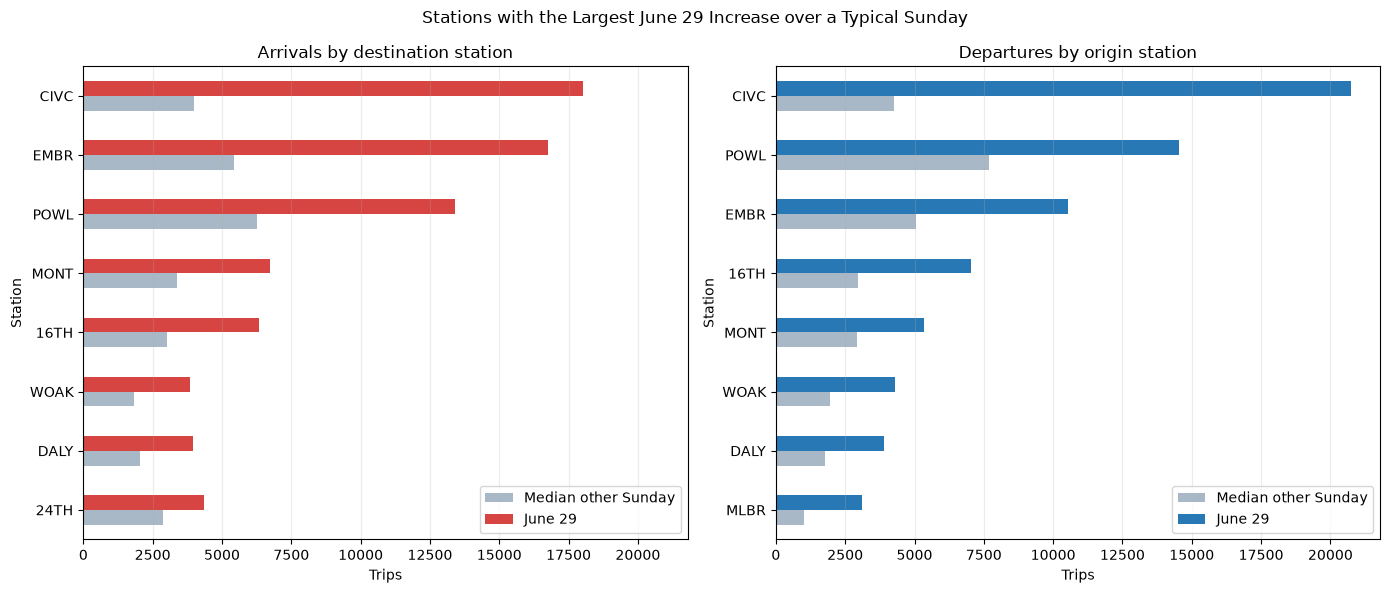

In [12]:
top_arrival_stations = (
    destination_comparison.nlargest(8, "Difference")
    .sort_values("Difference")
)
top_departure_stations = (
    origin_comparison.nlargest(8, "Difference")
    .sort_values("Difference")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

top_arrival_stations[["Median other Sunday", "June 29"]].plot.barh(
    ax=axes[0],
    color=["#A9B8C6", "#D64541"],
)
axes[0].set(title="Arrivals by destination station", xlabel="Trips", ylabel="Station")

top_departure_stations[["Median other Sunday", "June 29"]].plot.barh(
    ax=axes[1],
    color=["#A9B8C6", "#2878B5"],
)
axes[1].set(title="Departures by origin station", xlabel="Trips", ylabel="Station")

for ax in axes:
    ax.grid(axis="x", alpha=0.25)
    ax.legend(title="")

fig.suptitle("Stations with the Largest June 29 Increase over a Typical Sunday")
fig.tight_layout()
plt.show()

## 8. Current findings and limitations

June 29 emerged as the unexplained outlier only after checking other unusual dates, rather than being selected in advance because it was Pride. It was the busiest Sunday in the 2025 data, with **141,474 trips**, compared with a median of **77,504 trips** across the other Sundays—about **82.5% higher**. Civic Center shows the largest increase in both arrivals and departures, while Embarcadero, Powell Street, Montgomery Street, and 16th Street also show substantial increases. This station pattern is consistent with unusually high travel to and from central San Francisco on Pride Sunday.

The comparison remains descriptive. Using every other Sunday as the baseline does not control for seasonality, holidays, service changes, weather, or other events taking place on June 29. Pride is an obvious explanation for much of the unusually high ridership, particularly given the station-level pattern, but this comparison alone cannot tell us how many additional trips were caused by Pride.